Name :- Sarthak Balaji Zunjure

PRN :- 1252090003

Roll no :- 03

Assignment-6 Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following: a. Univariate analysis:
Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis b. Bivariate analysis: Linear and logistic regression
modeling c. Multiple Regression analysis d. Also compare the results of the above analysis for the two data sets.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score , confusion_matrix

In [ ]:
pima = pd.read_csv('diabetes.csv')
print("Pima Dataset Shape:", pima.shape)
pima.head()

Pima Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes = load_diabetes()
sklearn_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
sklearn_df['target'] = diabetes.target
print("Sklearn Diabetes Shape:",sklearn_df.shape)
sklearn_df.head()

Sklearn Diabetes Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
sklearn_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [ ]:
sklearn_df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [ ]:
pima.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
def univariate_analysis(df):
  result = pd. DataFrame({
  "Mean": df.mean(),
  "Median": df.median(),
  "Mode": df.mode().iloc[0],
  "Variance": df.var(),
  "Std Dev": df.std(),
  "Skewness": df.skew(),
  "Kurtosis": df.kurt()
})
  return result
print("Univariate Analysis - Pima Dataset")
print(univariate_analysis(pima))

print("\nUnivariate Analysis - Sklearn Diabetes Dataset")
print(univariate_analysis(sklearn_df))

Univariate Analysis - Pima Dataset
                                Mean    Median    Mode      Variance  \
Pregnancies                 3.845052    3.0000   1.000     11.354056   
Glucose                   120.894531  117.0000  99.000   1022.248314   
BloodPressure              69.105469   72.0000  70.000    374.647271   
SkinThickness              20.536458   23.0000   0.000    254.473245   
Insulin                    79.799479   30.5000   0.000  13281.180078   
BMI                        31.992578   32.0000  32.000     62.159984   
DiabetesPedigreeFunction    0.471876    0.3725   0.254      0.109779   
Age                        33.240885   29.0000  22.000    138.303046   
Outcome                     0.348958    0.0000   0.000      0.227483   

                             Std Dev  Skewness  Kurtosis  
Pregnancies                 3.369578  0.901674  0.159220  
Glucose                    31.972618  0.173754  0.640780  
BloodPressure              19.355807 -1.843608  5.180157  
SkinThic

Single Linear Regression

Linear Regression Result:
Coefficient: [988.41931249]
Intercept: 151.04202449316014
R2 Score: 0.2803417492440603
MSE: 3884.936720961032


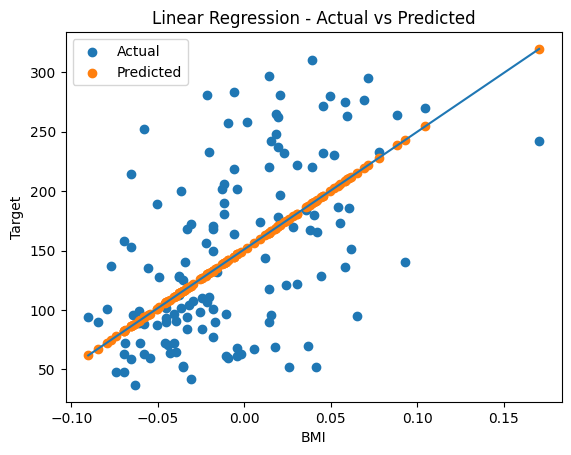

In [ ]:
x = sklearn_df[['bmi']]
y = sklearn_df['target']
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size=0.3,random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(x_train,y_train)
y_pred = lin_reg.predict(x_test)

print("Linear Regression Result:")
print("Coefficient:",lin_reg.coef_)
print("Intercept:",lin_reg.intercept_)
print("R2 Score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

plt.figure()
sorted_index = x_test['bmi' ]. argsort()
X_test_sorted = x_test.iloc[sorted_index]
y_test_sorted = y_test.iloc[sorted_index]
y_pred_sorted = y_pred[sorted_index]

plt.scatter(X_test_sorted, y_test_sorted, label="Actual")

plt.scatter(X_test_sorted, y_pred_sorted, label="Predicted")

plt.plot(X_test_sorted, y_pred_sorted)

plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Linear Regression - Actual vs Predicted")
plt.legend()
plt.show()

Multiple Linear Regression

Multiple Linear Regression (sklearn Dataset) Result:
R2 score: 0.4772897164322617
MSE: 2821.750981001311


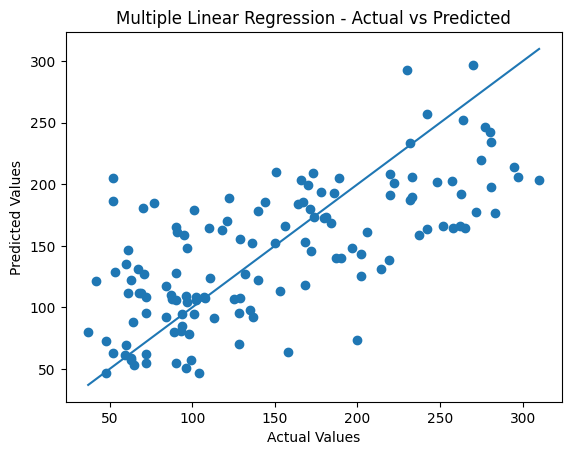

In [ ]:
x = sklearn_df.drop(columns=['target'])
y = sklearn_df['target']
x_train, x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42)
multi_lin_reg = LinearRegression()
multi_lin_reg.fit(x_train,y_train)
y_pred = multi_lin_reg.predict(x_test)

print("Multiple Linear Regression (sklearn Dataset) Result:")
print("R2 score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

plt.figure()

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
[y_test.min(), y_test.max()])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression - Actual vs Predicted")
plt.show()

Single Logistic Regtression

Logistic Regression Result:
Accuracy: 0.7229437229437229
Confusion Matrix: [[128  23]
 [ 41  39]]


Text(0.5, 1.0, 'Single Logistic Regression - Scatter Plot')

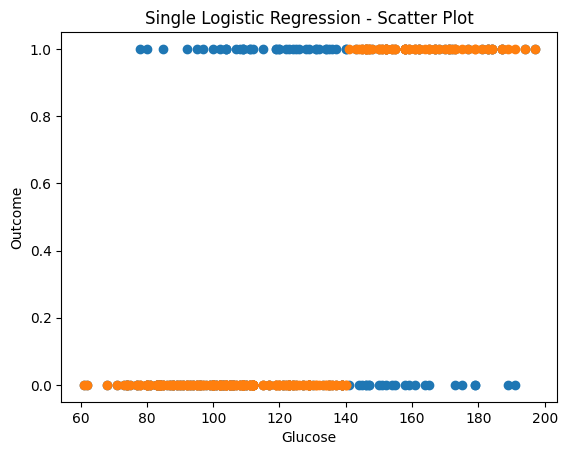

In [ ]:
x = pima[['Glucose']]
y = pima['Outcome']
x_train, x_test, y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42)
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)
y_pred = log_reg.predict(x_test)

print("Logistic Regression Result:")
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

plt.figure()

plt.scatter(x_test, y_test, label="Actual")
plt.scatter(x_test, y_pred, label="Predicted")

plt.xlabel("Glucose")
plt.ylabel("Outcome")
plt.title("Single Logistic Regression - Scatter Plot")

Multiple Logistic Regression

Multiple Logistic Regression (Pima Dataset) Result:
Accuracy: 0.7359307359307359
Confusion Matrix: [[120  31]
 [ 30  50]]


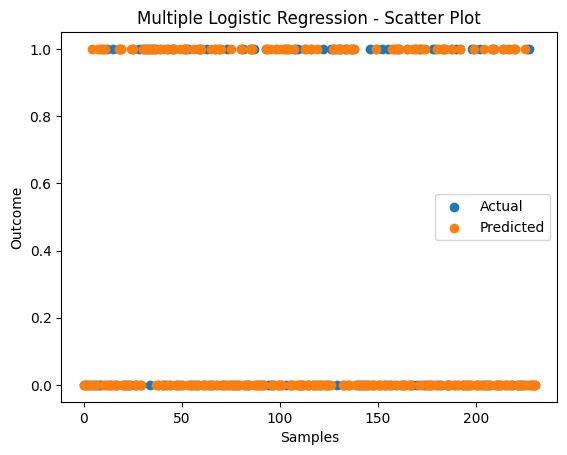



Comparsion

            Dataset  Samples  Features   Target Type
0      diabetes.csv      768         8  Binary (0/1)
1  Sklearn Diabetes      442        10    Continuous


In [ ]:
x = pima.drop(columns=['Outcome' ])
y = pima['Outcome']

x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
multi_log_reg = LogisticRegression(max_iter=2000)
multi_log_reg.fit(x_train,y_train)
y_pred = multi_log_reg.predict(x_test)
print("Multiple Logistic Regression (Pima Dataset) Result:")
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

plt.figure()
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.xlabel("Samples")
plt.ylabel("Outcome")
plt.title("Multiple Logistic Regression - Scatter Plot")
plt.legend()
plt.show()

#Comparison
print("\n\nComparsion\n")
comparison_info = pd.DataFrame({
"Dataset": ["diabetes.csv", "Sklearn Diabetes"],
"Samples": [pima.shape[0], sklearn_df.shape[0]],
"Features": [pima.shape[1]-1, sklearn_df.shape[1]-1],
"Target Type": ["Binary (0/1)", "Continuous"]

})

print(comparison_info)